![Insper](https://github.com/danielscarvalho/Insper-DS-Dicas/blob/master/Insper-Logo.png?raw=true)

# Insper Pós-Graduação
## Programa Avançado em Data Science e Decisão [»](https://www.insper.edu.br/pt/cursos/pos-graduacao/programas-avancados/programas-avancados-data-science-e-decisao)

<b>Planilhas no mundo dos negócios são assustadoras!!!</b>

Planilhas com erros de formulas, dados errados, dados desatualizados, dados icompleto, diversas versões com pessoas e times diferentes, color coding, células agrupadas, sem chaves (IDs), chaves erradas, vazamento de dados sensíveis...

Planilhas NÃO COMPUTÁVEIS!!!

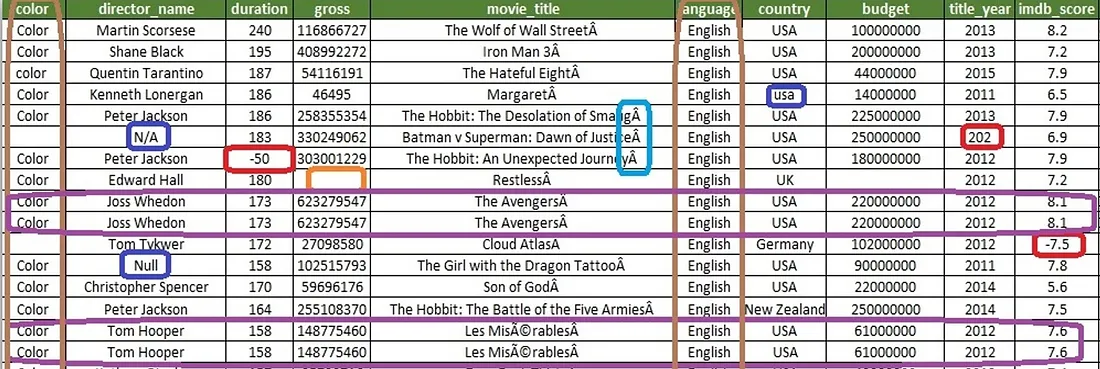<br>
https://medium.com/well-red/cleaning-a-messy-dataset-using-python-7d7ab0bf199b

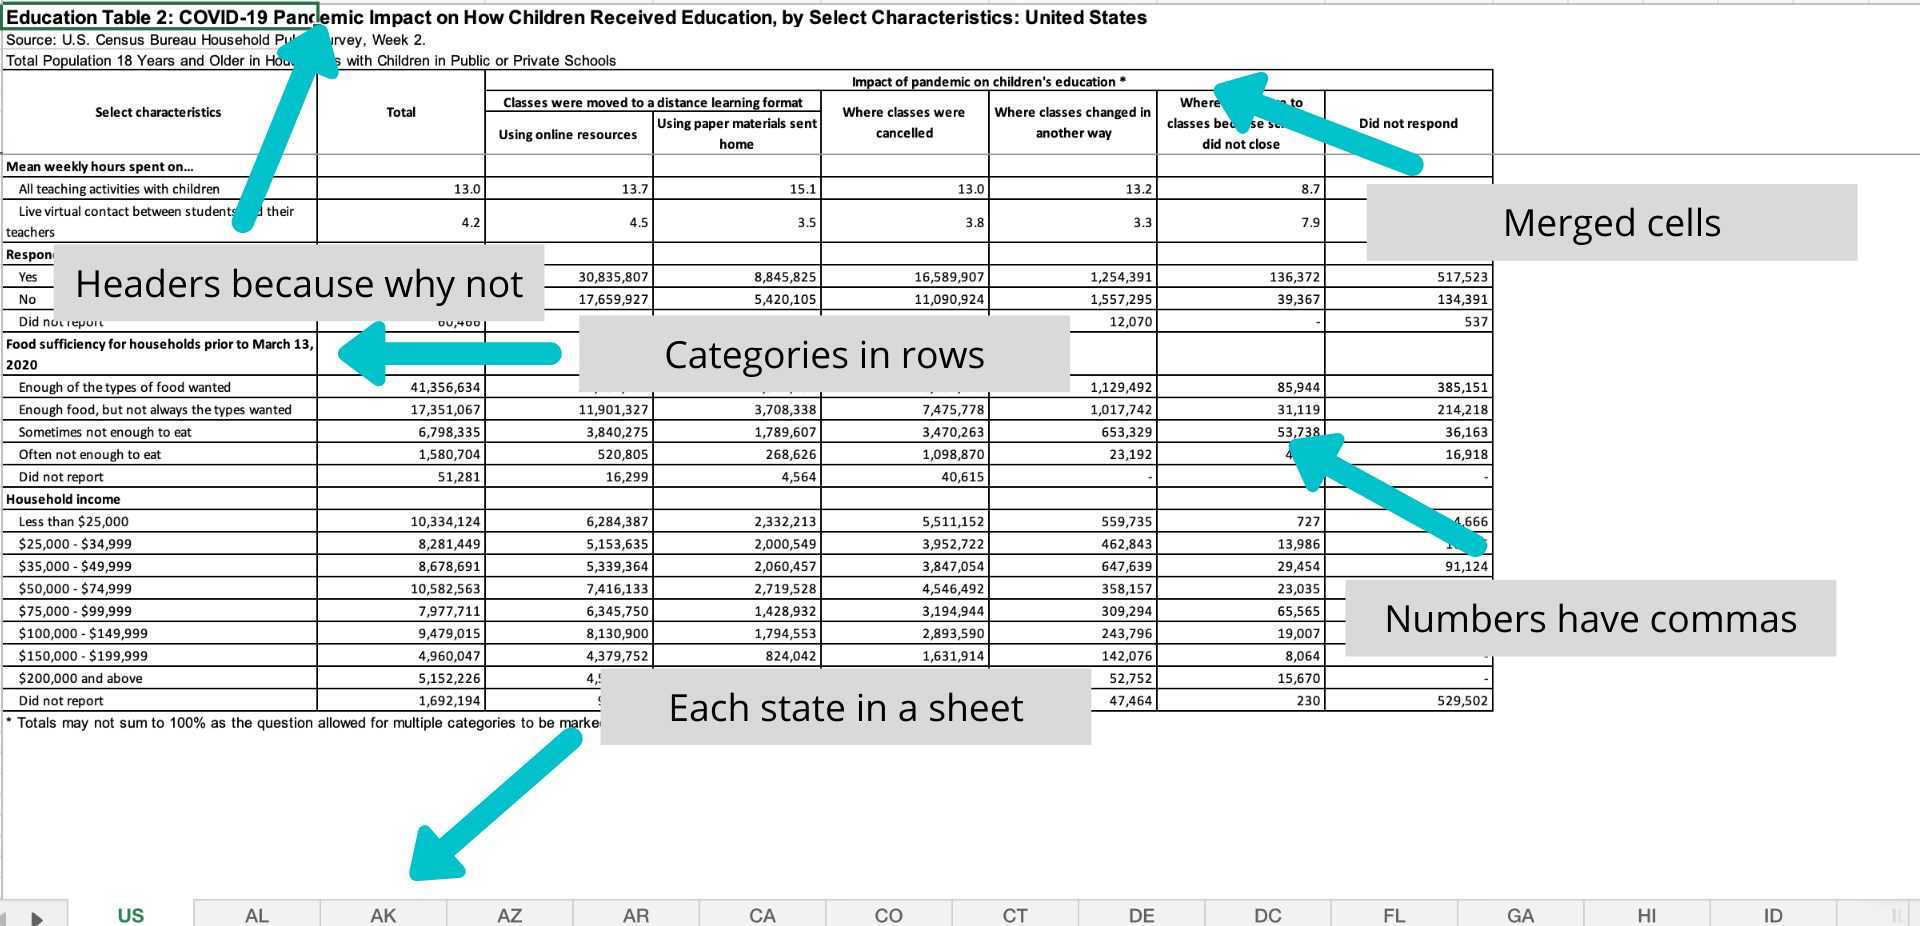<br>
https://ivelasq.rbind.io/blog/tidying-census-data/

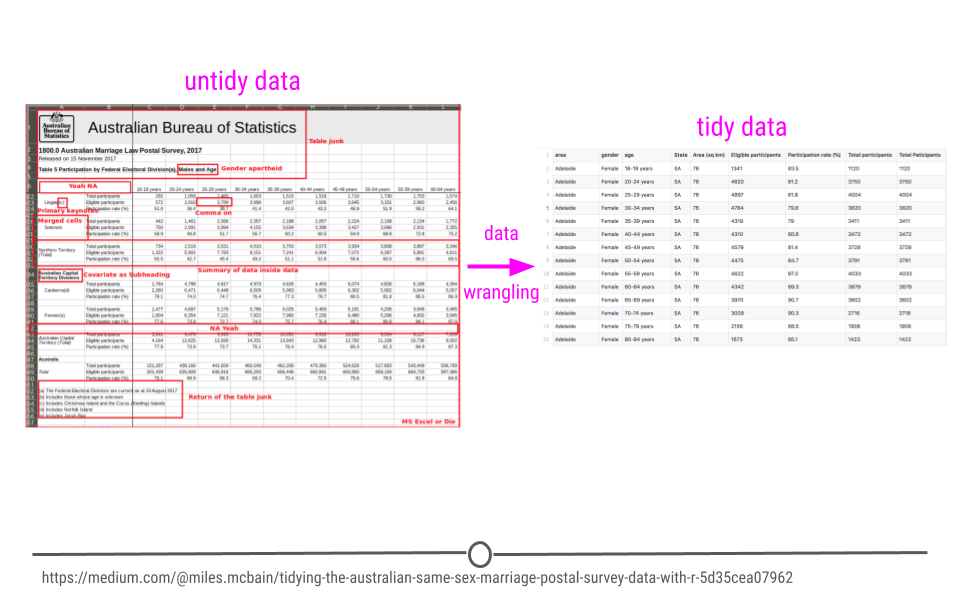<br>
https://jhudatascience.org/tidyversecourse/wrangle-data.html

[12 MODELLING HORROR STORIES & SPREADSHEET...](https://www.f1f9.com/wp-content/uploads/2019/04/F1F9_Dirty-Dozen_E-Book_01a.pdf)

Como os cientistas de dados gastam seu tempo (pesquisa):

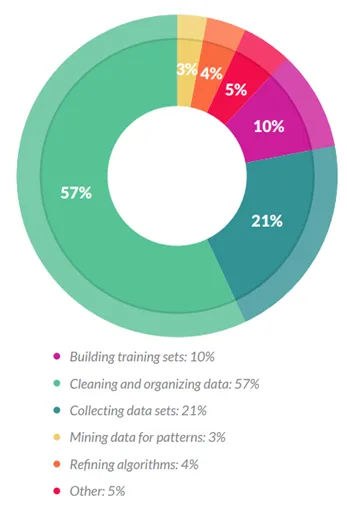

# Aula 05 - Tidy Data

Visão Geral:
    
![](https://d33wubrfki0l68.cloudfront.net/6f1ddb544fc5c69a2478e444ab8112fb0eea23f8/91adc/images/tidy-1.png)    

Dicas:

- Todas as colunas estão no formato de dados correto, por exemplo, números como numéricos e não como texto?
- Cada coluna tem um cabeçalho único, correto e simples? Por exemplo: "Idade" em vez de "Qual é sua idade?"
- Verificou duas vezes a codificação de caracteres? Quando você importa dados de CSV, por exemplo, a codificação de caracteres pode estar errada, o que pode resultar em caracteres especiais não sendo exibidos corretamente, por exemplo, "FÃÂ©dÃÂ©ration" em vez de "Fédération".
- Está usando a codificação de texto correta? No Brasil usamos ASCII, Latin e UTF-8.

Exemplos clássicos:

![](https://d33wubrfki0l68.cloudfront.net/3aea19108d39606bbe49981acda07696c0c7fcd8/2de65/images/tidy-9.png)

![](https://d33wubrfki0l68.cloudfront.net/8350f0dda414629b9d6c354f87acf5c5f722be43/bcb84/images/tidy-8.png)

![](https://d33wubrfki0l68.cloudfront.net/f6fca537e77896868fedcd85d9d01031930d76c9/637d9/images/tidy-17.png)

![](https://d33wubrfki0l68.cloudfront.net/3d98d3ba019fed3f9ee328284568d4508e479ef8/0b3e6/images/tidy-18.png)

Prática:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
#Talvez seja necessário no seu sistema...
#!pip3 install xlrd==1.2.0
#!conda install xldr

In [ ]:
dados = pd.read_excel('Bases/UN_MigrantStockByOriginAndDestination_2015.xlsx',                     
                      sheet_name='Table 15',
                      engine='openpyxl',
                      skiprows=15)

In [ ]:
type(dados)

In [ ]:
dados.head()

In [ ]:
dados.shape

In [ ]:
dados = dados[dados['Unnamed: 4'].notna()]

In [ ]:
dados.head()

In [ ]:
dados.drop(['Unnamed: 0', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'],
          axis=1 , inplace=True)

In [ ]:
dados = dados.rename(columns={'Unnamed: 1': 'Destination Country'})

In [ ]:
dados.drop(['Total'],
          axis=1 , inplace=True)
dados.head()

Tipos de dados:
- Dado estruturado - 30% - BD, tabular, folha de pagamento, estoque, ERP, CRM, Data Warehouse, Cartesiano (máquina)
- Dado não estruturado - 70% - Imagem, video, posts blog, mídia social, jornal, notícias, revista, livro, contrato (humano)

- OLTP - Transacional, dado corporativo, sistemas online, ERP, CRM, Folha... base de dados normalizada
- OLAP - Analítico, ETL, tabelas, mode de dados estrela - Data Warehouse - CUBO

### Transformando em Tidy Data

In [ ]:
dados_tidy = dados.melt(
id_vars=['Destination Country'], #variavel que quero manter na linha
var_name = 'Origin Country' , # nome que quero dar para a coluna que ira armazenar os valores das outras colunas
value_name = 'People'  #nome da nova coluna que armazena o valor da posicao destination country + coluna original 
)

In [ ]:
type(dados)

In [ ]:
type(dados_tidy)

In [ ]:
dados.head()

In [ ]:
dados_tidy.head(20)

### Visualizando com Altair

In [ ]:
dados_tidy.shape

In [ ]:
dados_tidy.dropna(axis=0, inplace=True)

In [ ]:
dados_tidy.shape

In [ ]:
dados_brasil = dados_tidy.query("`Destination Country` == 'Brazil' and People > 0")

In [ ]:
dados_brasil

In [ ]:
import altair as alt

In [ ]:
alt.Chart(dados_brasil.nlargest(10, 'People')).mark_bar().encode(
    x = alt.X('Origin Country', 
              title='País de Origem',
              sort='-y'),
    y = alt.Y('People'),
    tooltip = ['Origin Country',
               'People'],
).properties(
    title = 'Imigração feminina para o Brasil em 2010',
).interactive()

Columna com dados faltantes??!!

- Apagar linhas sem informação
- Preencher dados faltantes com:
    - Média
    - Moda
    - Mediana
    - Interpolação
    - Random
    - Zero
    - Próximo valor
    - Valor anterior
    - Regressão

### Referência

- https://pandas.pydata.org/
- https://altair-viz.github.io/
- https://vita.had.co.nz/papers/tidy-data.pdf
- https://r4ds.had.co.nz/tidy-data.html